In [1]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


In [2]:
ql = 20
ol = 30
system = fluxonium_oscillator_system(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = ql,
    osc_level = ol,
    kappa = 0.0005,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(25) ],
    computaional_states = '1,2',
    w_d = 7.16475
    )

tot_time =733 + 20
tlist = np.linspace(0, tot_time, tot_time)


In [3]:
system.a*system.a.dag()

Quantum object: dims = [[600], [600]], shape = (600, 600), type = oper, isherm = True
Qobj data =
[[ 1.00008299e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  -3.59264398e-05+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  1.00009106e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [-3.59264398e-05+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   1.00008713e+00+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 ...
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ...  1.38891090e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  7.57754353e-01+1.83586616e-05j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0

# 1 load result, truncate to 2-level

In [3]:
with open('../pickles/mesolve_temp_kappa1em3.pkl', 'rb') as file:
    results1 = pickle.load(file)

with open('../pickles/mesolve_temp_kappa5em4.pkl', 'rb') as file:
    results2 = pickle.load(file)


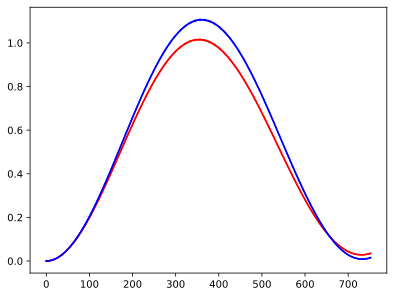

In [4]:
plt.plot(results1[0].expect[0],color = 'red')
plt.plot(results1[1].expect[0],color = 'red')

plt.plot(results2[0].expect[0],color = 'blue')
plt.plot(results2[1].expect[0],color = 'blue')

# plt.ylim(0,0.1)

In [5]:
for result in [results1[0],results1[1],results2[0],results2[1]]:
    result.twolevel_states = [dressed_to_2_level_dm(state, 
                                                    system.product_to_dressed, 
                                                    system.qubit_level,
                                                    system.osc_level,
                                                    system.computaional_states[0],
                                                    system.computaional_states[1],
                                                    products_to_keep=None)
                               for state in tqdm(result.states, desc=f"Processing states with {dressed_to_2_level_dm.__name__}")]
    

Processing states with dressed_to_2_level_dm:  17%|█▋        | 128/753 [00:11<00:58, 10.69it/s]

KeyboardInterrupt: 

Processing states with dressed_to_2_level_dm:  17%|█▋        | 128/753 [00:30<00:58, 10.69it/s]

Text(0.5, 0, 'ns')

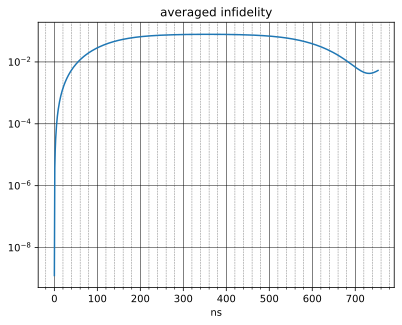

In [34]:
results = results1

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)


states_ideal  = [(zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(tot_time):
    dms = [result.twolevel_states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

Text(0.5, 0, 'ns')

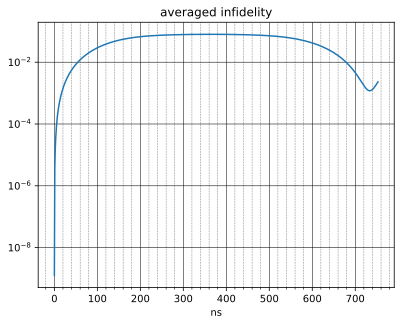

In [35]:
results = results2

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)


states_ideal  = [(zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(tot_time):
    dms = [result.twolevel_states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

In [36]:
ql = 2
ol = 3
system = fluxonium_oscillator_system(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = ql,
    osc_level = ol,
    kappa = 0.0005,
    products_to_keep=[[ql, ol] for ql in [0,1] for ol in range(3) ],
    computaional_states = '1,2',
    w_d = 7.16475
    )


In [47]:
system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,1)]))

Quantum object: dims = [[6], [1]], shape = (6, 1), type = ket
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]]

In [37]:
system.diag_dressed_hamiltonian

Quantum object: dims = [[6], [6]], shape = (6, 6), type = oper, isherm = True
Qobj data =
[[-4.24073792  0.          0.          0.          0.          0.        ]
 [ 0.          9.12625695  0.          0.          0.          0.        ]
 [ 0.          0.         40.77995457  0.          0.          0.        ]
 [ 0.          0.          0.         54.14595706  0.          0.        ]
 [ 0.          0.          0.          0.         85.8024095   0.        ]
 [ 0.          0.          0.          0.          0.         99.16890822]]

In [41]:
system.osc.annihilation_operator()

array([[0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.41421356],
       [0.        , 0.        , 0.        ]])

In [39]:
system.a_trunc

Quantum object: dims = [[6], [6]], shape = (6, 6), type = oper, isherm = False
Qobj data =
[[0.+0.00000000e+00j 0.-5.85132960e-03j 0.-9.99987912e-01j
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.-7.44101250e-08j]
 [0.+3.17215661e-03j 0.+0.00000000e+00j 0.+0.00000000e+00j
  0.+1.00001209e+00j 0.+3.82867163e-07j 0.+0.00000000e+00j]
 [0.-5.51132691e-06j 0.+0.00000000e+00j 0.+0.00000000e+00j
  0.+5.85045260e-03j 0.+1.41417513e+00j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 0.-5.51019057e-06j 0.-3.17183451e-03j
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.-1.41415803e+00j]
 [0.+0.00000000e+00j 0.+9.95923569e-08j 0.+3.54741346e-05j
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.+1.17017822e-02j]
 [0.-2.92715144e-08j 0.+0.00000000e+00j 0.+0.00000000e+00j
  0.-4.32669902e-05j 0.-6.34399112e-03j 0.+0.00000000e+00j]]

In [38]:
system.a_trunc+system.a_trunc.dag()


Quantum object: dims = [[6], [6]], shape = (6, 6), type = oper, isherm = True
Qobj data =
[[0.+0.00000000e+00j 0.-9.02348620e-03j 0.-9.99982401e-01j
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.-4.51386106e-08j]
 [0.+9.02348620e-03j 0.+0.00000000e+00j 0.+0.00000000e+00j
  0.+1.00001760e+00j 0.+2.83274807e-07j 0.+0.00000000e+00j]
 [0.+9.99982401e-01j 0.+0.00000000e+00j 0.+0.00000000e+00j
  0.+9.02228711e-03j 0.+1.41413965e+00j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 0.-1.00001760e+00j 0.-9.02228711e-03j
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.-1.41411477e+00j]
 [0.+0.00000000e+00j 0.-2.83274807e-07j 0.-1.41413965e+00j
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.+1.80457733e-02j]
 [0.+4.51386106e-08j 0.+0.00000000e+00j 0.+0.00000000e+00j
  0.+1.41411477e+00j 0.-1.80457733e-02j 0.+0.00000000e+00j]]

In [49]:
system.a_trunc*system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,1)]))

Quantum object: dims = [[6], [1]], shape = (6, 1), type = ket
Qobj data =
[[0.+0.00000000e+00j]
 [0.+1.00001209e+00j]
 [0.+5.85045260e-03j]
 [0.+0.00000000e+00j]
 [0.+0.00000000e+00j]
 [0.-4.32669902e-05j]]